# Task 4 — Email Spam Detection with Machine Learning

## Objective

Build an NLP binary classifier that distinguishes spam messages from legitimate (ham) messages.
## Workflow

Dataset → Cleaning → Preprocessing → Train/Test Split → TF-IDF → 3 Models → Evaluation → Best Model → Confusion Matrix → WordCloud


## Dataset
Kaggle. SMS Spam Collection Dataset. https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [2]:
# Import libraries
import os
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
os.makedirs("outputs/figures", exist_ok=True)
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\88019\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Load the Dataset
The dataset is hosted in my GitHub repository and loaded directly using its raw GitHub URL. Original Source: Kaggle

In [4]:
# Load the dataset

url = "https://raw.githubusercontent.com/SiamWR/dataset/refs/heads/main/Spam.csv"

df = pd.read_csv(url)
df = pd.read_csv(url, encoding="latin-1")

# Keep the two meaningful columns
df = df.iloc[:, :2]

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Dataset Inspection


In [5]:
# Inspect 

print("Dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (5572, 2)

Column names: ['label', 'message']

Data types:
label      str
message    str
dtype: object

Missing values:
label      0
message    0
dtype: int64


## 3. Class Distribution

Check spam and ham counts and percentages as required.


In [7]:
class_counts = df["label"].value_counts()

class_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_distribution

,Count,Percentage
label,,
ham,4825,86.59
spam,747,13.41


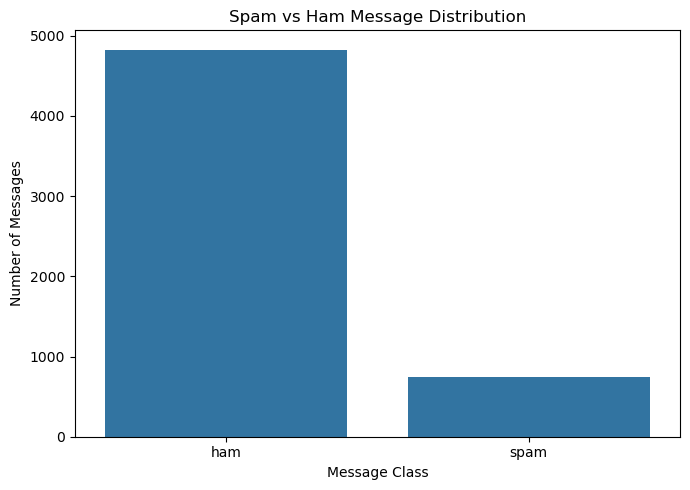

In [8]:
# Visualize class distribution

plt.figure(figsize=(7, 5))
sns.barplot(
    x=class_distribution.index,
    y=class_distribution["Count"]
)

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Class")
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.show()

## 4. Data Cleaning — Duplicate Check


In [9]:
# Check duplicate rows

df.duplicated().sum()

403

In [10]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

df.shape

(5169, 2)

## 5. Text Preprocessing

Required preprocessing:
- Lowercase conversion
- Punctuation removal
- Stopword removal

In [11]:
# Load English stopwords

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Lowercase conversion
    text = text.lower()

    # Punctuation removal
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Stopword removal
    words = [
        word for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
# Apply preprocessing

df["clean_message"] = df["message"].apply(preprocess_text)

df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [13]:
# Verify

display(df[["message", "clean_message"]].head(10))

empty_messages = df["clean_message"].str.strip().eq("").sum()
print("Empty cleaned messages:", empty_messages)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 weeks word back id like ...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile 11 months u r entitled update latest co...


Empty cleaned messages: 5


In [14]:
# Inspect messages that became empty after preprocessing

empty_rows = df[
    df["clean_message"].str.strip().eq("")
]

empty_rows[["label", "message", "clean_message"]]

,label,message,clean_message
939,ham,Where @,
2675,ham,Can a not?,
3191,ham,:),
4276,ham,:( but your not here....,
4500,ham,:-) :-),


In [15]:
empty_rows["label"].value_counts()

label
ham    5
Name: count, dtype: int64

In [16]:
# Remove messages that became empty after preprocessing

df = df[
    df["clean_message"].str.strip() != ""
].reset_index(drop=True)

df.shape

(5164, 3)

In [17]:
df["clean_message"].str.strip().eq("").sum()

0

In [18]:
class_counts = df["label"].value_counts()

class_percentages = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

final_class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

final_class_distribution

,Count,Percentage
label,,
ham,4511,87.35
spam,653,12.65


## 6. Prepare Features and Target

`0` represents ham and `1` represents spam.


In [19]:
# Define input text and binary target

X = df["clean_message"]

y = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry 2 wkly comp win fa cup final tkts 2...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: clean_message, dtype: str

Target:
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


## 7. Train/Test Split

The split is performed **before fitting TF-IDF** so that the test set does not influence vocabulary learning.


In [20]:
# Split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 4131
Testing samples: 1033


## 8. TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that machine learning models can process.

It measures how important a word is within a message relative to the collection of messages. A word receives a higher TF-IDF value when it is frequent in a particular message but relatively uncommon across the collection.


In [21]:
# TF-IDF

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train_text)

# Transform test text using the training vocabulary
X_test = vectorizer.transform(X_test_text)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (4131, 8229)
Testing feature shape: (1033, 8229)


In [22]:
# Inspect 
feature_names = vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("First 20 features:")
print(feature_names[:20])

Number of TF-IDF features: 8229
First 20 features:
['008704050406' '0089my' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414' '020903'
 '021' '050703' '0578' '06' '060505' '061104' '07090201529']


## 9. Model Training

Three classifiers are used:

1. Multinomial Naive Bayes — required text-classification baseline
2. Logistic Regression — alternative linear classifier
3. Linear SVM — additional classifier suitable for high-dimensional TF-IDF features


In [23]:
# Define the three classifiers

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        random_state=42
    )
}

In [24]:
# Train all classifiers and generate test predictions

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name} trained successfully.")

Multinomial Naive Bayes trained successfully.
Logistic Regression trained successfully.
Linear SVM trained successfully.


## 10. Model Evaluation

Models are evaluated using accuracy, precision, recall, and F1-score.


In [25]:
# Evaluation function

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [26]:
# Compare all three classifiers

results = []

for name, y_pred in predictions.items():
    metrics = evaluate_model(y_test, y_pred)
    results.append({
        "Model": name,
        **metrics
    })

results_df = pd.DataFrame(results)
results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.967086,1.000000,0.740458,0.850877
1,Logistic Regression,0.951597,0.945055,0.656489,0.774775
2,Linear SVM,0.984511,0.975207,0.900763,0.936508


In [24]:
# Detailed classification reports

for name, y_pred in predictions.items():
    print(f"\n{name}")
    print("=" * len(name))
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"]
        )
    )


Multinomial Naive Bayes
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       902
        Spam       1.00      0.75      0.86       131

    accuracy                           0.97      1033
   macro avg       0.98      0.87      0.92      1033
weighted avg       0.97      0.97      0.97      1033


Logistic Regression
              precision    recall  f1-score   support

         Ham       0.95      0.99      0.97       902
        Spam       0.95      0.66      0.78       131

    accuracy                           0.95      1033
   macro avg       0.95      0.83      0.88      1033
weighted avg       0.95      0.95      0.95      1033


Linear SVM
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       902
        Spam       0.97      0.89      0.93       131

    accuracy                           0.98      1033
   macro avg       0.98      0.94      0.96      1033
weighted avg    

## 11. Select the Best-Performing Model

The model with the highest F1-score is selected automatically. F1-score balances precision and recall.


In [27]:
# Select best model by F1-score

best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_predictions = predictions[best_model_name]

print("Best-performing model:", best_model_name)

Best-performing model: Linear SVM


## 12. Confusion Matrix


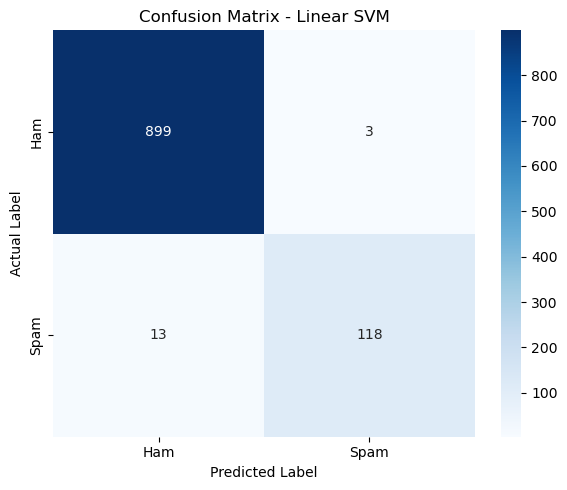

In [28]:
# Confusion matrix for the best model

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.savefig(
    "outputs/figures/confusion_matrix_linear_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Why is Recall Particularly Important for Spam Detection?

Recall measures the proportion of actual spam messages that the classifier successfully identifies.

Recall is particularly important because a false negative occurs when an actual spam message is classified as legitimate (ham). A high recall helps reduce missed spam messages and improves the system's ability to detect unwanted messages.


## 14. WordCloud Visualizations

In [29]:
# Optional WordCloud dependency

from wordcloud import WordCloud

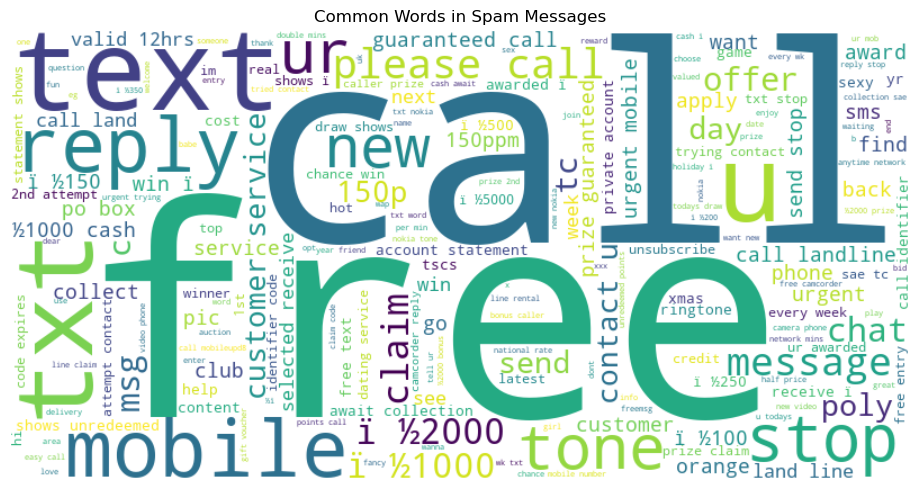

In [30]:
# Spam WordCloud

spam_text = " ".join(
    df.loc[df["label"] == "spam", "clean_message"]
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.tight_layout()

plt.savefig(
    "outputs/figures/spam_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

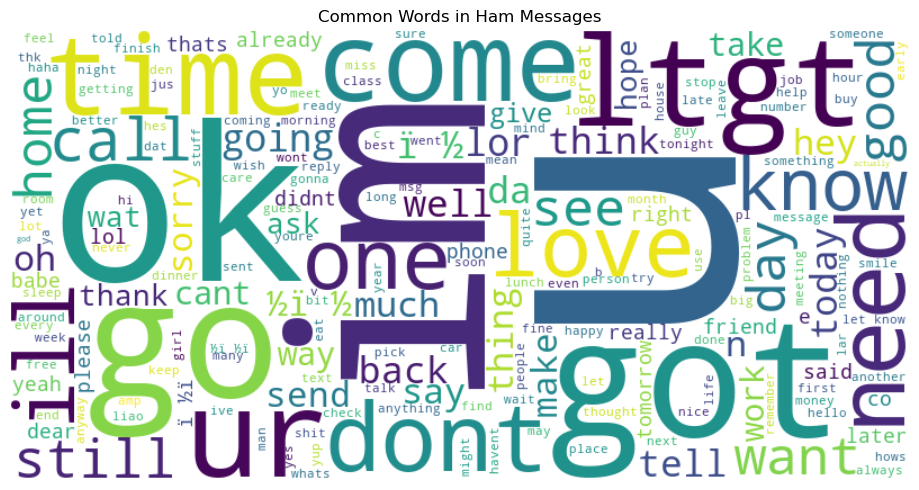

In [31]:
# Ham WordCloud

ham_text = " ".join(
    df.loc[df["label"] == "ham", "clean_message"]
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.tight_layout()

plt.savefig(
    "outputs/figures/ham_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 15. Conclusion

This project developed an NLP-based binary classifier for distinguishing spam from legitimate messages.

It included text preprocessing, TF-IDF feature extraction, train/test splitting, and training three classifiers: Multinomial Naive Bayes, Logistic Regression, and Linear SVM.

The models were compared using accuracy, precision, recall, and F1-score, with particular attention to recall because missed spam messages are false negatives.

## References

1. Kaggle. SMS Spam Collection Dataset. https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

2. NLTK Documentation. Natural Language Toolkit.
   https://www.nltk.org/

3. scikit-learn Documentation. Feature Extraction and Classification.
   https://scikit-learn.org/